# AR & FOXA1 in LNCaP (±DHT)

How the **androgen receptor (AR)** cistrome depends on the pioneer factor
**FOXA1** after androgen (DHT) stimulation in LNCaP cells.

Data are ChIP-Atlas (hg38) peaks + bigwigs — run `./download_data.sh` first.
LNCaP, 0h vs 4h DHT, for FOXA1, AR, and ATAC-seq (two ATAC replicates / condition).

> **Note** — The reference paths in the next cell point at the lackgrp cluster;
> edit them for your environment.

## 0. Setup — paths & helpers

In [1]:
import os, time
from contextlib import contextmanager

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import genomeblocks as gb
from genomeblocks import Loci, Genes, Atlas, make_genome, tmm
from genomeblocks.signal_draw import plot_heatmap
from genomeblocks.motifs import scan_motifs_matrix, bootstrap_enrichment
from genomeblocks.browser import browser


@contextmanager
def timer(label):
    """Print a step's wall-clock time."""
    t0 = time.perf_counter()
    print(f"\u25b6 {label} ...")
    try:
        yield
    finally:
        print(f"\u2713 {label} \u2014 {time.perf_counter() - t0:.1f}s")


# --- downloaded data (see download_data.sh) ---
DATA = "data"
DATA
SRX = {
    "FOXA1_0h": "SRX23002839", "FOXA1_4h": "SRX23002841",
    "AR_0h":    "SRX23002834", "AR_4h":    "SRX23002836",
    "ATAC_0h_r1": "SRX23002894", "ATAC_0h_r2": "SRX23002895",
    "ATAC_4h_r1": "SRX23002898", "ATAC_4h_r2": "SRX23002899",
}
PEAK = {k: f"{DATA}/{s}.05.bed" for k, s in SRX.items()}
BW   = {k: f"{DATA}/{s}.bw"     for k, s in SRX.items()}

# --- hg38 references (edit for your environment) ---
GENOME_FA   = "/groups/lackgrp/genome_annotations/hg38/hg38.fa"
GTF         = "/groups/lackgrp/genome_annotations/hg38/gencode.v49.annotation_protein_coding.gtf"
MOTIF_DB    = "/groups/lackgrp/databases/motifs/motif-db/H14CORE_jaspar_format_lightmotif.txt"
CHROMSIZES  = "/groups/lackgrp/genome_annotations/hg38/hg38_chr.chrom.sizes"
GIGGLE_META = "/groups/lackgrp/databases/giggle/giggle_hg38/hg38_tfs_meta.tsv"
GIGGLE_DIR  = "/groups/lackgrp/databases/giggle/giggle_hg38/ChIP-Atlas-ALL"

## 1. Load peaks

In [2]:
with timer("load peak files"):
    peaks = {k: Loci.make(v) for k, v in PEAK.items()}

for k, v in peaks.items():
    print(f"{k:12} {len(v):>8,} peaks")

▶ load peak files ...
✓ load peak files — 1.0s
FOXA1_0h        8,657 peaks
FOXA1_4h       10,870 peaks
AR_0h             910 peaks
AR_4h           3,645 peaks
ATAC_0h_r1     53,671 peaks
ATAC_0h_r2     62,741 peaks
ATAC_4h_r1     47,780 peaks
ATAC_4h_r2     51,196 peaks


## 2. Accessible chromatin — union of ATAC peaks

Concatenate the four ATAC peak sets (both conditions, both reps) and `merge()`
overlapping intervals into one accessible-region set.

In [3]:
with timer("ATAC union (accessible regions)"):
    accessible = (peaks["ATAC_0h_r1"] + peaks["ATAC_0h_r2"]
                  + peaks["ATAC_4h_r1"] + peaks["ATAC_4h_r2"]).sort().merge()

print(f"accessible regions (merged): {len(accessible):,}")

▶ ATAC union (accessible regions) ...
✓ ATAC union (accessible regions) — 0.7s
accessible regions (merged): 72,470


## 3. AR / FOXA1 binding inside vs outside accessible chromatin

AR_0h       31.2% inside accessible (284/910)
AR_4h       83.0% inside accessible (3,027/3,645)
FOXA1_0h    85.0% inside accessible (7,362/8,657)
FOXA1_4h    88.0% inside accessible (9,561/10,870)


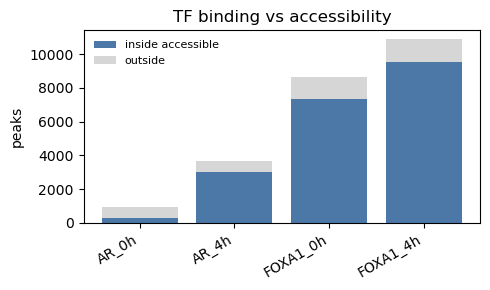

In [4]:
rows = []
for name in ["AR_0h", "AR_4h", "FOXA1_0h", "FOXA1_4h"]:
    s = peaks[name]
    inside = len(s & accessible)              # peaks overlapping accessible
    total = len(s)
    rows.append((name, inside, total - inside))
    print(f"{name:10} {100 * inside / total:5.1f}% inside accessible ({inside:,}/{total:,})")

names = [r[0] for r in rows]
ins   = np.array([r[1] for r in rows])
outs  = np.array([r[2] for r in rows])
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(names, ins,  label="inside accessible", color="#4c78a8")
ax.bar(names, outs, bottom=ins, label="outside", color="#d6d6d6")
ax.set_ylabel("peaks"); ax.legend(frameon=False, fontsize=8)
ax.set_title("TF binding vs accessibility")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()

## 4. Keep only accessible TF peaks

In [5]:
with timer("filter TF peaks to accessible"):
    F0 = peaks["FOXA1_0h"] & accessible
    F4 = peaks["FOXA1_4h"] & accessible
    A4 = peaks["AR_4h"]    & accessible

print(f"accessible  FOXA1 0h={len(F0):,}  FOXA1 4h={len(F4):,}  AR 4h={len(A4):,}")

▶ filter TF peaks to accessible ...
✓ filter TF peaks to accessible — 0.0s
accessible  FOXA1 0h=7,362  FOXA1 4h=9,561  AR 4h=3,027


## 5. Venn — FOXA1 (0h, 4h) vs AR (4h)

To venn genomic intervals we merge all peaks into a shared region *universe*,
then label each region by which input set overlaps it. From this:

- **AR+F** = AR 4h peaks that overlap FOXA1 (0h or 4h) — FOXA1-dependent AR
- **AR−F** = AR 4h peaks that overlap no FOXA1 peak — FOXA1-independent AR

▶ venn3 membership ...


venn membership: 100%|██████████| 11624/11624 [00:00<00:00, 142827.06it/s]

✓ venn3 membership — 0.2s


Text(0.5, 1.0, 'Accessible peaks: FOXA1 (0h, 4h) vs AR (4h)')

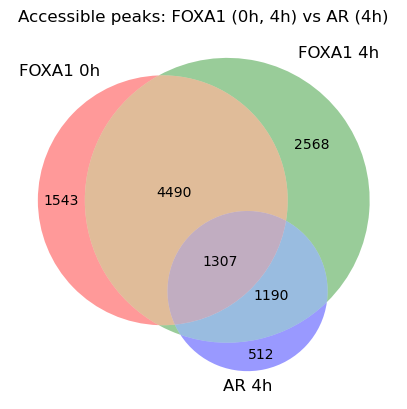

In [ ]:
from matplotlib_venn import venn3

fig, ax = plt.subplots(figsize=(5, 5))
venn3((F0, F4, A4), set_labels=["FOXA1 0h", "FOXA1 4h", "AR 4h"], ax=ax)
ax.set_title("Accessible peaks: FOXA1 (0h, 4h) vs AR (4h)")

In [18]:
with timer("define AR+F / AR-F"):
    ARpF  = A4 & F4 & F0                   # AR 4h that IS FOXA1-bound the baseline
    ARmF  = A4 & F4 - F0                   # AR 4h that is NOT FOXA1-bound in the baseline

print(f"AR+F (FOXA1-dependent): {len(ARpF):,}   AR-F (FOXA1-independent): {len(ARmF):,}")

▶ define AR+F / AR-F ...
✓ define AR+F / AR-F — 0.0s
AR+F (FOXA1-dependent): 1,308   AR-F (FOXA1-independent): 1,191


## 6. Signal heatmaps across conditions

Extract signal for AR+F and AR−F over all 8 bigwigs, average the two ATAC
replicates per condition (the same averaging the browser does), and draw a
grouped heatmap: ATAC 0h, ATAC 4h, AR 0h, AR 4h, FOXA1 0h, FOXA1 4h.

▶ extract signal cube ...
[INFO] Extracting 8 bigwigs for 2499 loci into 200 bins (span=False, agg='mean', backend='pybigtools', exact=True, workers=4).


chunks:   0%|          | 0/4 [00:00<?, ?it/s]

chunks: 100%|██████████| 4/4 [00:04<00:00,  1.11s/it]


✓ extract signal cube — 4.5s
▶ draw heatmap ...
✓ draw heatmap — 0.1s


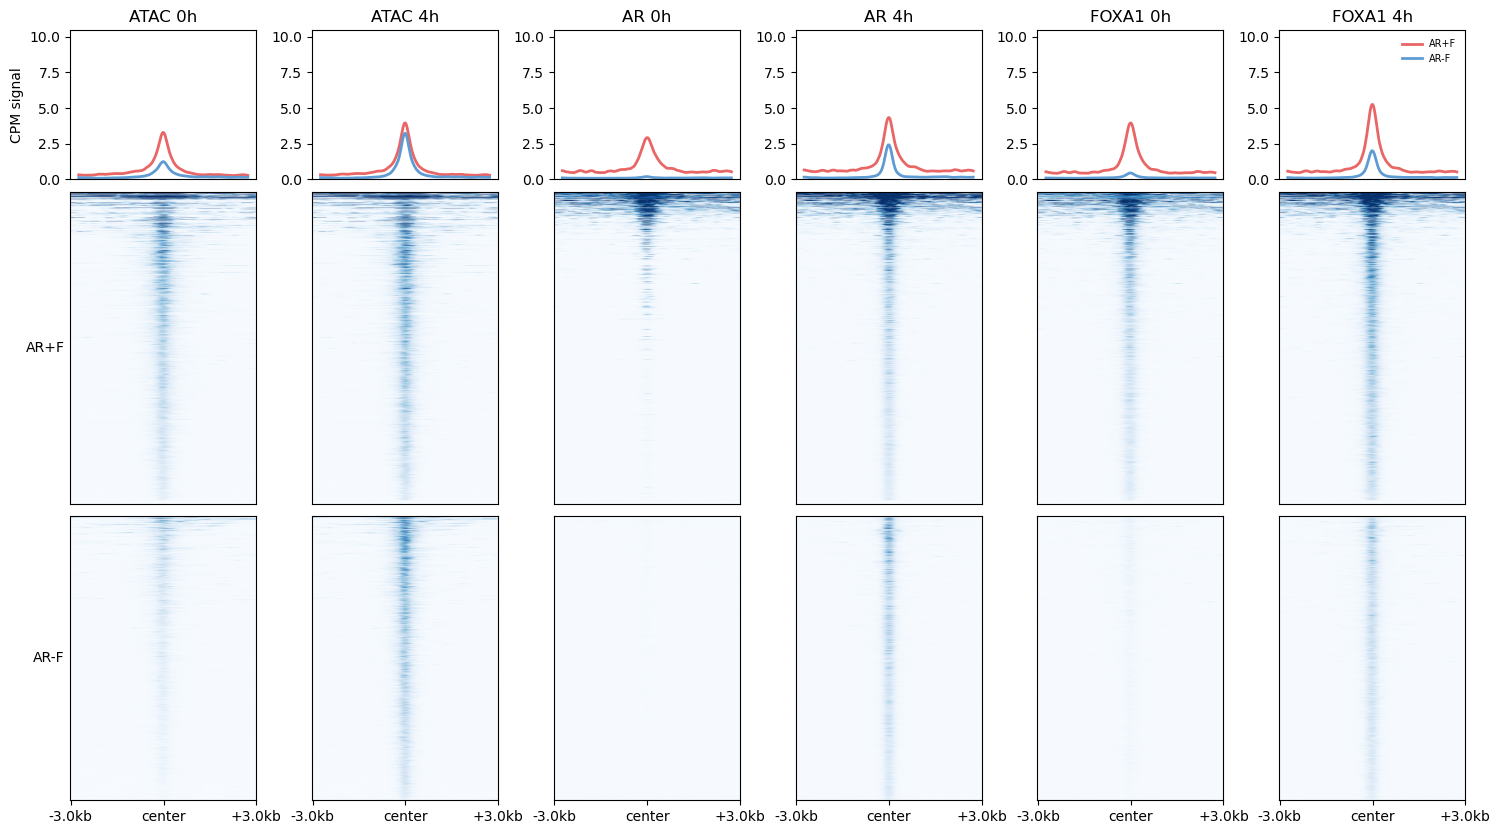

In [33]:
regions = ARpF + ARmF
groups  = {"AR+F": ARpF, "AR-F": ARmF}

bw_order = ["ATAC_0h_r1", "ATAC_0h_r2", "ATAC_4h_r1", "ATAC_4h_r2",
            "AR_0h", "AR_4h", "FOXA1_0h", "FOXA1_4h"]
bigwigs = [BW[k] for k in bw_order]

with timer("extract signal cube"):
    S = np.nan_to_num(regions.signal(bigwigs, n_bins=200, flank=2000, workers=4))

# group ATAC replicates by averaging their columns -> 6 conditions
S6 = np.stack([
    S[:, [0, 1], :].mean(1),   # ATAC 0h (rep1+rep2)
    S[:, [2, 3], :].mean(1),   # ATAC 4h (rep1+rep2)
    S[:, 4, :], S[:, 5, :],    # AR 0h, AR 4h
    S[:, 6, :], S[:, 7, :],    # FOXA1 0h, FOXA1 4h
], axis=1)
samples = ["ATAC 0h", "ATAC 4h", "AR 0h", "AR 4h", "FOXA1 0h", "FOXA1 4h"]
vmax = float(np.percentile(S6, 99))



with timer("draw heatmap"):
    fig = plot_heatmap(regions, S6, groups=groups, sets=["AR+F", "AR-F"],
                        colors={'AR+F': '#E96666', 'AR-F': '#5F9BD3'},
                        samples=samples, vmax=vmax, ymax=vmax)

## 7. Genomic annotation of AR+F vs AR−F

▶ annotate AR+F / AR-F ...
✓ annotate AR+F / AR-F — 0.0s


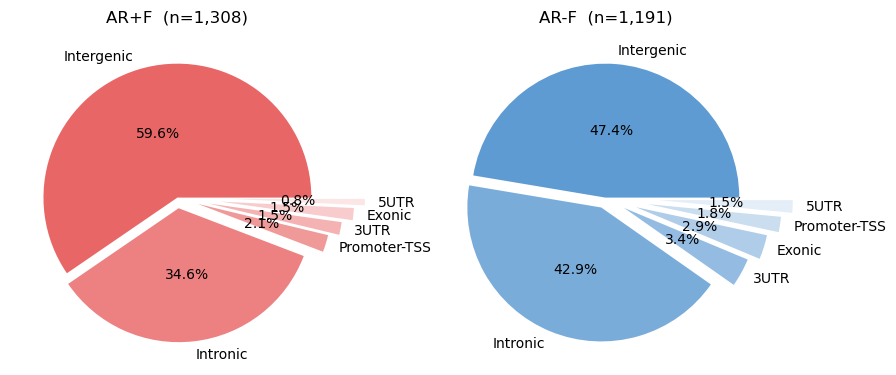

In [ ]:
def generate_fades(color, K):
	from matplotlib.colors import to_rgb
	import colorsys
	r, g, b = to_rgb(color)
	h, l, s = colorsys.rgb_to_hls(r, g, b)
	fades = []
	for i in range(K):
		# increase lightness for fade effect
		new_l = min(1, l + (i * (1 - l) / K))
		new_r, new_g, new_b = colorsys.hls_to_rgb(h, new_l, s)
		fades.append((new_r, new_g, new_b))
	return fades


with timer("load genes (GTF)"):
    genes = Genes.make(GTF)

with timer("annotate AR+F / AR-F"):
    annot_pf = genes.annotations(ARpF)
    annot_mf = genes.annotations(ARmF)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, df, title, palette in [(axes[0], annot_pf, "AR+F", '#E96666'), (axes[1], annot_mf, "AR-F", '#5F9BD3')]:
    vc = df["annotation"].value_counts()
    ax.pie(vc.values, labels=vc.index, \
        autopct='%1.1f%%', startangle=0, explode=np.linspace(0,0.4,len(vc.index)), pctdistance=0.5, labeldistance=1.1, \
        colors=generate_fades(palette, len(vc.index))
    )
    ax.set_title(f"{title}  (n={len(df):,})")
plt.tight_layout()

## 8. Motif enrichment — AR+F vs AR−F

Scan JASPAR motifs over AR+F, AR−F, and a subsample of the accessible (ATAC)
pool as background, then bootstrap the log-fold-change. Sorting by `LFC`
(= LFC_AR+F − LFC_AR−F) gives motifs preferential to each set.

In [ ]:
with timer("load genome FASTA"):
    genome = make_genome(GENOME_FA)

# background pool = subsample of accessible chromatin (keeps scanning cheap)
pool = accessible

with timer("scan motifs (AR+F, AR-F, pool)"):
    mat_pf   = scan_motifs_matrix(ARpF, genome, MOTIF_DB, r=250, workers=8)
    mat_mf   = scan_motifs_matrix(ARmF, genome, MOTIF_DB, r=250, workers=8)
    mat_pool = scan_motifs_matrix(pool, genome, MOTIF_DB, r=250, workers=8)

with timer("bootstrap enrichment"):
    enr = bootstrap_enrichment({"AR+F": mat_pf, "AR-F": mat_mf},
                               ref=mat_pool, boot=100, sample=500, seed=0)

show = ["Factor", "LFC", "LFC_AR+F", "LFC_AR-F"]
ranked = enr.sort_values("LFC", ascending=False)
print("Top motifs in AR+F (FOXA1-inbaseline):")
display(ranked.head(10)[show])
print("Top motifs in AR-F (FOXA1-Later):")
display(ranked.tail(10)[show].iloc[::-1])

▶ load genome FASTA ...
✓ load genome FASTA — 20.4s
▶ scan motifs (AR+F, AR-F, pool) ...


[motifs]: 100%|██████████| 33/33 [00:31<00:00,  1.04it/s]


✓ scan motifs (AR+F, AR-F, pool) — 55.4s
▶ bootstrap enrichment ...


100%|██████████| 100/100 [00:00<00:00, 221.48it/s]

✓ bootstrap enrichment — 2.2s
Top motifs in AR+F (FOXA1-dependent):


,Factor,LFC,LFC_AR+F,LFC_AR-F
1439,ZN671.H14CORE.0.P.C,0.365856,0.350358,-0.015497
1098,TSH2.H14CORE.0.SG.A,0.287228,0.282964,-0.004264
1409,ZN595.H14CORE.0.P.C,0.091514,0.088861,-0.002653
1257,ZN224.H14CORE.0.P.B,0.083552,0.078561,-0.004991
1574,ZNF85.H14CORE.1.P.B,0.081333,0.076025,-0.005307
302,GLI4.H14CORE.0.P.C,0.076867,0.075945,-0.000921
1006,STA5B.H14CORE.0.P.B,0.069988,0.066869,-0.003118
256,FOXH1.H14CORE.0.P.B,0.060096,0.055328,-0.004769
959,SOX30.H14CORE.0.P.C,0.058751,0.059350,0.000598
1083,THA.H14CORE.1.PS.A,0.055440,0.057698,0.002258


Top motifs in AR-F (FOXA1-independent):


,Factor,LFC,LFC_AR+F,LFC_AR-F
7,ANDR.H14CORE.0.P.B,-0.099527,0.031241,0.130768
9,ANDR.H14CORE.2.P.B,-0.087289,0.058832,0.146121
836,PRGR.H14CORE.0.P.B,-0.076962,0.030474,0.107436
1137,Z585A.H14CORE.0.P.C,-0.057039,-0.013839,0.043200
293,GCR.H14CORE.0.PS.A,-0.052016,0.009729,0.061745
1416,ZN613.H14CORE.0.P.C,-0.050554,0.064787,0.115342
557,MCR.H14CORE.0.S.B,-0.041988,0.007692,0.049680
1315,ZN384.H14CORE.0.PSM.A,-0.040429,-0.021896,0.018532
103,CPEB1.H14CORE.1.S.B,-0.040029,0.028405,0.068434
253,FOXE1.H14CORE.1.S.C,-0.034728,0.025207,0.059935


## 9. ChIP-Atlas (atlas) differential enrichment

Build a 1 kb bin × track index over the ChIP-Atlas hg38 collection, then use
each region set as the other's reference to find TF tracks differentially
enriched between AR+F and AR−F.

> Building the index over the full ChIP-Atlas is heavy (minutes, several GB
> RAM). Pickle `atlas` to reuse it across sessions.

In [11]:
with timer("build ChIP-Atlas index (1kb)"):
    atlas = Atlas.make(
        GIGGLE_DIR, chromsizes=CHROMSIZES,
        meta=GIGGLE_META,
        name_pattern=r"([^.]+)",                       # SRX23002840.20.bed.gz -> SRX23002840
        meta_columns=["id", "antigen", "class", "cell_line"],  # meta TSV is header-less
        meta_id_col="id",
    )

with timer("atlas search AR+F vs AR-F"):
    enr_pf = atlas.search(ARpF, ref=ARmF)    # enriched in AR+F over AR-F
    enr_mf = atlas.search(ARmF, ref=ARpF)    # enriched in AR-F over AR+F

cols = ["name", "antigen", "class", "cell_line", "overlaps", "log2_odds", "giggle_score"]
print("TF tracks enriched in AR+F (FOXA1-dependent):")
display(enr_pf.head(15)[cols])
print("TF tracks enriched in AR-F (FOXA1-independent):")
display(enr_mf.head(15)[cols])

▶ build ChIP-Atlas index (1kb) ...


[atlas index]: 100%|██████████| 33368/33368 [00:31<00:00, 1072.54it/s]


✓ build ChIP-Atlas index (1kb) — 70.2s
▶ atlas search AR+F vs AR-F ...
✓ atlas search AR+F vs AR-F — 8.4s
TF tracks enriched in AR+F (FOXA1-dependent):


,name,antigen,class,cell_line,overlaps,log2_odds,giggle_score
0,SRX23002840,FOXA1,Prostate,LNCAP,1329,7.519583,964.923631
1,SRX23002841,FOXA1,Prostate,LNCAP,1089,7.056433,700.212091
2,SRX18285237,FOXA1,Prostate,LNCAP,1847,4.287255,618.551089
3,SRX14353424,FOXA1,Prostate,LNCAP,1990,4.058525,604.652460
4,SRX18285235,FOXA1,Prostate,LNCAP,1722,4.333244,580.711304
5,SRX062360,FOXA1,Prostate,LNCAP,1564,4.546911,564.964852
6,SRX14353423,FOXA1,Prostate,LNCAP,1756,4.155838,548.736062
7,SRX5577144,Epitope tags,Prostate,LNCAP,1779,4.090175,540.034633
8,SRX1885188,FOXA1,Prostate,LNCAP,2044,3.775184,533.691700
9,SRX18285236,FOXA1,Prostate,LNCAP,1470,4.498439,515.002750


TF tracks enriched in AR-F (FOXA1-independent):


,name,antigen,class,cell_line,overlaps,log2_odds,giggle_score
0,SRX3070471,NR3C1,Breast,MCF 10A,151,1.985641,57.274594
1,SRX3070475,NR3C1,Breast,MCF 10A,120,2.021899,49.016228
2,SRX21439743,ESR1,Prostate,LNCAP,452,1.518987,46.612336
3,SRX3070473,NR3C1,Breast,MCF 10A,120,1.969408,45.866518
4,SRX306516,AR,Prostate,DU 145,161,1.690385,39.808143
5,SRX19970679,AR,Prostate,PC-346C,167,1.537133,31.894465
6,SRX8520802,NR3C1,Breast,HCC1187,173,1.506006,31.057426
7,SRX21439744,ESR1,Prostate,LNCAP,336,1.292770,30.240255
8,SRX3070469,NR3C1,Breast,MCF 10A,53,2.255766,30.173945
9,SRX21439742,ESR1,Prostate,LNCAP,295,1.284194,28.358706


## 10. Browser view — `chr19:50,792,009-50,923,669`

All six conditions as signal tracks (ATAC replicates passed as a **list** of
bigwigs are averaged into one track), their peak calls, and gene models.

▶ browser render ...
✓ browser render — 0.9s


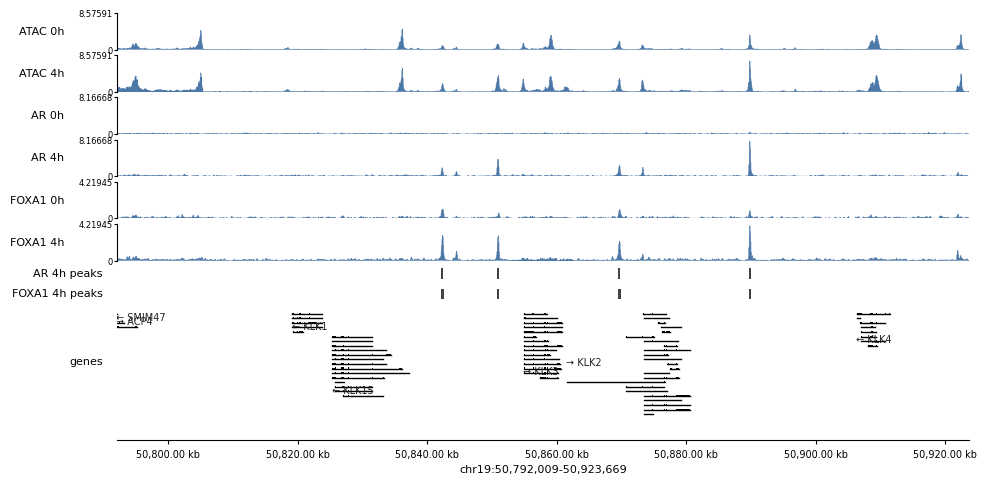

In [12]:
region = "chr19:50,792,009-50,923,669"
tracks = {
    "ATAC 0h":   [BW["ATAC_0h_r1"], BW["ATAC_0h_r2"]],   # list -> averaged
    "ATAC 4h":   [BW["ATAC_4h_r1"], BW["ATAC_4h_r2"]],
    "AR 0h":     BW["AR_0h"],
    "AR 4h":     BW["AR_4h"],
    "FOXA1 0h":  BW["FOXA1_0h"],
    "FOXA1 4h":  BW["FOXA1_4h"],
    "AR 4h peaks":    PEAK["AR_4h"],
    "FOXA1 4h peaks": PEAK["FOXA1_4h"],
    "genes":     genes,
}
# share the y-axis within each assay so the 0h -> 4h gain is honest
with timer("browser render"):
    fig, axes = browser(region, tracks, bw_n_bins=2000, figsize=(11, None),
                        bw_share=[["ATAC 0h", "ATAC 4h"],
                                  ["AR 0h", "AR 4h"],
                                  ["FOXA1 0h", "FOXA1 4h"]])